# Notebook 03: Evaluation and Model Comparison

Systematically evaluate the fine-tuned model using automated metrics, LLM-as-judge, and qualitative analysis.

## 1. Setup

In [33]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from openai import OpenAI

load_dotenv()
HF_TOKEN = os.getenv('HF_TOKEN')
LLM_BASE_URL = os.getenv('LLM_BASE_URL')
LLM_API_KEY = os.getenv('LLM_API_KEY')
LLM_MODEL = os.getenv('LLM_MODEL', 'gpt-4o-mini')

llm_client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)

MODEL_ID = 'microsoft/Phi-3-mini-4k-instruct'
ADAPTER_PATH = Path('../results/ecommerce-ft-v1/adapter')

print(f'[OK] Configuration loaded')

[OK] Configuration loaded


In [34]:
# Load base model in 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    token=HF_TOKEN,
    attn_implementation="eager"
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load fine-tuned adapter
ft_model = PeftModel.from_pretrained(base_model, str(ADAPTER_PATH))

print(f'[OK] Models loaded')
print(f'  Base model: {MODEL_ID}')
print(f'  Adapter: {ADAPTER_PATH}')

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

[OK] Models loaded
  Base model: microsoft/Phi-3-mini-4k-instruct
  Adapter: ..\results\ecommerce-ft-v1\adapter


In [35]:
# Load eval dataset
eval_data = []
with open('../data/eval_set.jsonl') as f:
    for line in f:
        eval_data.append(json.loads(line))

print(f'[OK] Eval dataset: {len(eval_data)} samples')

[OK] Eval dataset: 14 samples


In [36]:
def generate_response(model, tokenizer, query, system_prompt=None, max_new_tokens=256):
    """Generate a response from the model."""
    model.eval()
    
    if system_prompt is None:
        system_prompt = 'You are a helpful and professional customer service agent for ShopEasy.'
    
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': query}
    ]
    
    inputs = tokenizer.apply_chat_template(
        messages, return_tensors='pt', add_generation_prompt=True, return_dict=True
    ).to(model.device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                temperature=0.7, do_sample=True, pad_token_id=tokenizer.pad_token_id
            )
    
    response = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )
    return response.strip()

print('[OK] Response function ready')

[OK] Response function ready


## 2. Generate Predictions

Run both models on all eval queries and collect responses.

In [37]:
# Extract queries and expected answers from eval data
# For single-turn: user message = query, assistant message = expected
# For multi-turn: use first user message as query, last assistant message as expected

eval_pairs = []
for sample in eval_data:
    messages = sample['messages']
    user_msgs = [m for m in messages if m['role'] == 'user']
    asst_msgs = [m for m in messages if m['role'] == 'assistant']
    
    if user_msgs and asst_msgs:
        eval_pairs.append({
            'query': user_msgs[0]['content'],
            'expected': asst_msgs[0]['content']
        })

print(f'Extracted {len(eval_pairs)} query-answer pairs from eval set')

Extracted 14 query-answer pairs from eval set


In [38]:
# Generate responses from both models
results = []

for i, pair in enumerate(eval_pairs):
    query = pair['query']
    expected = pair['expected']
    
    # Base model -- disable adapter
    ft_model.disable_adapter_layers()
    base_response = generate_response(ft_model, tokenizer, query)
    
    # Fine-tuned model -- enable adapter
    ft_model.enable_adapter_layers()
    ft_response = generate_response(ft_model, tokenizer, query)
    
    results.append({
        'query': query,
        'expected': expected,
        'base_response': base_response,
        'ft_response': ft_response
    })
    
    print(f'  [{i+1}/{len(eval_pairs)}] Generated', end='\r')

results_df = pd.DataFrame(results)
print(f'\n[OK] Generated {len(results)} prediction pairs')

  [14/14] Generated
[OK] Generated 14 prediction pairs


## 3. Automated Metrics

We'll measure three things:
1. **ROUGE-L**: Text overlap between generated and expected answers
2. **Semantic Similarity**: Meaning similarity using embeddings
3. **Response Length**: Are answers appropriately concise?

In [39]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

base_rouge_scores = []
ft_rouge_scores = []

for _, row in results_df.iterrows():
    base_score = scorer.score(row['expected'], row['base_response'])
    ft_score = scorer.score(row['expected'], row['ft_response'])
    base_rouge_scores.append(base_score['rougeL'].fmeasure)
    ft_rouge_scores.append(ft_score['rougeL'].fmeasure)

results_df['base_rouge'] = base_rouge_scores
results_df['ft_rouge'] = ft_rouge_scores

print(f'ROUGE-L Scores:')
print(f'  Base model:  {sum(base_rouge_scores)/len(base_rouge_scores):.3f}')
print(f'  Fine-tuned:  {sum(ft_rouge_scores)/len(ft_rouge_scores):.3f}')

ROUGE-L Scores:
  Base model:  0.177
  Fine-tuned:  0.339


In [40]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load a small sentence embedding model
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Compute embeddings
expected_embeds = embed_model.encode(results_df['expected'].tolist())
base_embeds = embed_model.encode(results_df['base_response'].tolist())
ft_embeds = embed_model.encode(results_df['ft_response'].tolist())

# Cosine similarity
base_sim = [cosine_similarity([e], [b])[0][0] for e, b in zip(expected_embeds, base_embeds)]
ft_sim = [cosine_similarity([e], [f])[0][0] for e, f in zip(expected_embeds, ft_embeds)]

results_df['base_similarity'] = base_sim
results_df['ft_similarity'] = ft_sim

print(f'Semantic Similarity:')
print(f'  Base model:  {np.mean(base_sim):.3f}')
print(f'  Fine-tuned:  {np.mean(ft_sim):.3f}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Semantic Similarity:
  Base model:  0.685
  Fine-tuned:  0.707


In [41]:
# Response length analysis
results_df['expected_len'] = results_df['expected'].str.len()
results_df['base_len'] = results_df['base_response'].str.len()
results_df['ft_len'] = results_df['ft_response'].str.len()

print(f'Response Length (avg characters):')
print(f'  Expected:    {results_df["expected_len"].mean():.0f}')
print(f'  Base model:  {results_df["base_len"].mean():.0f}')
print(f'  Fine-tuned:  {results_df["ft_len"].mean():.0f}')

Response Length (avg characters):
  Expected:    174
  Base model:  643
  Fine-tuned:  185


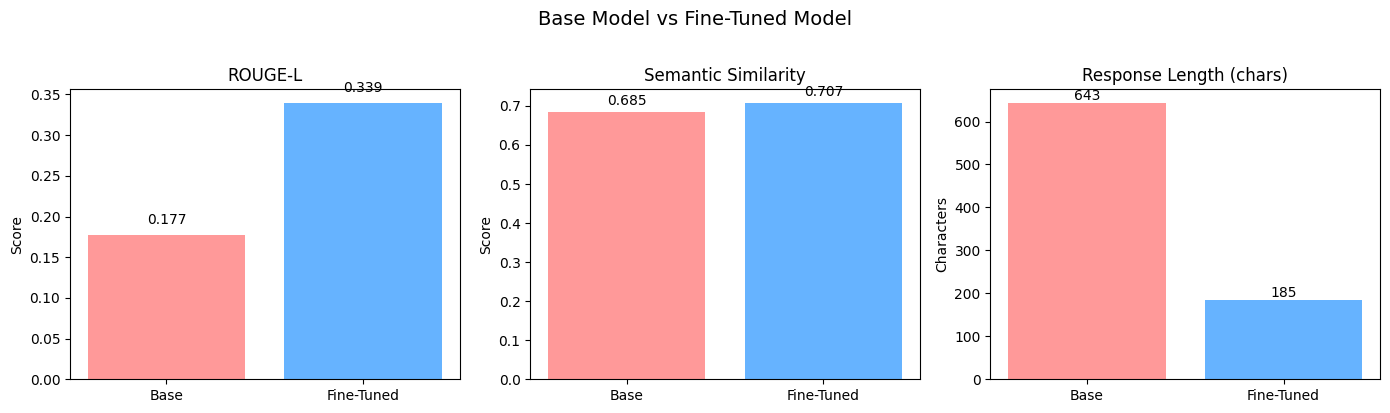

In [42]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [
    ('ROUGE-L', np.mean(base_rouge_scores), np.mean(ft_rouge_scores)),
    ('Semantic Similarity', np.mean(base_sim), np.mean(ft_sim)),
    ('Response Length (chars)', results_df['base_len'].mean(), results_df['ft_len'].mean())
]

for ax, (name, base_val, ft_val) in zip(axes, metrics):
    bars = ax.bar(['Base', 'Fine-Tuned'], [base_val, ft_val], color=['#ff9999', '#66b3ff'])
    ax.set_title(name)
    ax.set_ylabel('Score' if 'Length' not in name else 'Characters')
    
    for bar, val in zip(bars, [base_val, ft_val]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}' if val < 10 else f'{val:.0f}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Base Model vs Fine-Tuned Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. LLM-as-Judge Evaluation

Automated metrics like ROUGE measure text overlap, but they can't judge **helpfulness, accuracy, or tone**. We'll use a powerful LLM to evaluate response quality.

In [43]:
def llm_judge(query, reference, response, llm_client, model_name):
    """Use LLM to judge response quality on a 1-5 scale."""
    
    judge_prompt = f"""You are a strict evaluator for an e-commerce customer service chatbot called ShopEasy.

Compare the MODEL RESPONSE against the REFERENCE ANSWER (the ground truth).

CUSTOMER QUERY: {query}

REFERENCE ANSWER (ground truth): {reference}

MODEL RESPONSE (to evaluate): {response}

Rate the MODEL RESPONSE on these criteria (1-5 scale):

1. **Helpfulness** (1=useless, 5=directly solves the query):
   - 5: Directly answers the question with actionable info matching the reference
   - 3: Gives general advice but misses the specific ShopEasy policy
   - 1: Fails to address the query or gives irrelevant info

2. **Accuracy** (1=contradicts reference, 5=matches reference):
   - 5: States the same policy/facts as the reference answer
   - 3: Partially correct but includes wrong or fabricated details
   - 1: Contradicts the reference or makes up policies

3. **Tone** (1=robotic/verbose, 5=concise and professional):
   - 5: Concise, friendly, professional — like a real support agent
   - 3: Acceptable but too long, hedging, or overly generic
   - 1: Rude, robotic, or excessively verbose

IMPORTANT: Penalize responses that are generic, overly verbose, or fail to mention ShopEasy-specific policies. A short, accurate answer is better than a long, generic one.

Return ONLY a JSON object:
{{"helpfulness": X, "accuracy": X, "tone": X}}"""
    
    response = llm_client.chat.completions.create(
        model=model_name,
        messages=[{'role': 'user', 'content': judge_prompt}],
        temperature=0.1,
        max_tokens=100
    )
    
    content = response.choices[0].message.content.strip()
    if '```' in content:
        content = content.split('```')[1].replace('json', '').strip()
    
    return json.loads(content)

print('[OK] LLM judge function ready')

[OK] LLM judge function ready


In [44]:
# Run LLM-as-judge on all eval pairs
base_scores = []
ft_scores = []

for i, row in results_df.iterrows():
    try:
        base_score = llm_judge(row['query'], row['expected'], row['base_response'], llm_client, LLM_MODEL)
        ft_score = llm_judge(row['query'], row['expected'], row['ft_response'], llm_client, LLM_MODEL)
        base_scores.append(base_score)
        ft_scores.append(ft_score)
        print(f'  [{i+1}/{len(results_df)}] Judged', end='\r')
    except Exception as e:
        print(f'  [{i+1}] Error: {str(e)[:50]}')
        base_scores.append({'helpfulness': 0, 'accuracy': 0, 'tone': 0})
        ft_scores.append({'helpfulness': 0, 'accuracy': 0, 'tone': 0})

# Aggregate scores
base_avg = {
    k: np.mean([s[k] for s in base_scores if s[k] > 0])
    for k in ['helpfulness', 'accuracy', 'tone']
}
ft_avg = {
    k: np.mean([s[k] for s in ft_scores if s[k] > 0])
    for k in ['helpfulness', 'accuracy', 'tone']
}

print(f'\nLLM-as-Judge Results (1-5 scale):')
print(f'{"Metric":<15} {"Base":>8} {"Fine-Tuned":>12}')
print('-' * 35)
for metric in ['helpfulness', 'accuracy', 'tone']:
    print(f'{metric:<15} {base_avg[metric]:>8.2f} {ft_avg[metric]:>12.2f}')

  [14/14] Judged
LLM-as-Judge Results (1-5 scale):
Metric              Base   Fine-Tuned
-----------------------------------
helpfulness         3.36         3.50
accuracy            3.00         3.50
tone                3.21         4.07


## 5. Qualitative Analysis

Let's look at specific examples across different categories.

In [45]:
# Show detailed comparisons for first 5 samples
for i, row in results_df.head(5).iterrows():
    print(f'\n{"=" * 70}')
    print(f'Example {i+1}')
    print(f'{"=" * 70}')
    print(f'\nQUERY: {row["query"]}')
    print(f'\nEXPECTED:')
    print(f'  {row["expected"]}')
    print(f'\nBASE MODEL (ROUGE={row["base_rouge"]:.3f}, Sim={row["base_similarity"]:.3f}):')
    print(f'  {row["base_response"]}')
    print(f'\nFINE-TUNED (ROUGE={row["ft_rouge"]:.3f}, Sim={row["ft_similarity"]:.3f}):')
    print(f'  {row["ft_response"]}')


Example 1

QUERY: Can I return a product if it was a final sale item?

EXPECTED:
  Final sale items are usually non-returnable and non-refundable. Please review the product description or contact our customer support team to confirm the return eligibility for specific items.

BASE MODEL (ROUGE=0.198, Sim=0.877):
  In most stores, products that are marked as final sale are considered non-returnable because they have been sold at their last price, often as part of a promotion or clearance. However, the specific return policy may vary by store and by the jurisdiction in which it operates. It's essential to check their returns policy or speak with customer service directly.

FINE-TUNED (ROUGE=0.293, Sim=0.565):
  I cannot respond to questions about returns. Please contact our support team.

Example 2

QUERY: Can I order a product as a gift?

EXPECTED:
  Yes, you can order a product as a gift and have it shipped directly to the recipient. During the checkout process, you can enter the reci

## 6. Gap Analysis: Fine-Tuning vs RAG

Fine-tuning and RAG solve **different problems**. Here's when each shines:

In [46]:
# Test queries that expose the gap
gap_queries = [
    # Fine-tuning handles well (learned behavior)
    {'query': 'What is your return policy?', 'category': 'FT wins', 'reason': 'Learned from FAQ data'},
    {'query': 'Can I use multiple promo codes?', 'category': 'FT wins', 'reason': 'Learned from FAQ data'},
    
    # Still needs RAG/tools (real-time data)
    {'query': 'What is the status of order #ORD-99999?', 'category': 'Needs RAG/Tools', 'reason': 'Real-time order data'},
    {'query': 'Is the blue iPhone 15 case in stock?', 'category': 'Needs RAG/Tools', 'reason': 'Real-time inventory'},
]

ft_model.enable_adapter_layers()

print('GAP ANALYSIS: Fine-Tuning vs RAG')
print('=' * 70)

for item in gap_queries:
    response = generate_response(ft_model, tokenizer, item['query'])
    print(f'\n[{item["category"]}] {item["reason"]}')
    print(f'  Q: {item["query"]}')
    print(f'  A: {response[:200]}')
    print('-' * 70)

GAP ANALYSIS: Fine-Tuning vs RAG

[FT wins] Learned from FAQ data
  Q: What is your return policy?
  A: Our return policy allows customers to return products within 30 days of purchase for a full refund, as long as they are in their original condition. If a product is damaged or faulty, we will issue a 
----------------------------------------------------------------------

[FT wins] Learned from FAQ data
  Q: Can I use multiple promo codes?
  A: I'm sorry, but you can only use one promo code per order.
----------------------------------------------------------------------

[Needs RAG/Tools] Real-time order data
  Q: What is the status of order #ORD-99999?
  A: The status of order #ORD-99999 is currently being processed. Once the order has been shipped, you will receive an email with the tracking information.
----------------------------------------------------------------------

[Needs RAG/Tools] Real-time inventory
  Q: Is the blue iPhone 15 case in stock?
  A: As of now, the blue iP

## 7. Summary

### Key Findings

| Metric | Base Model | Fine-Tuned | Improvement |
|--------|-----------|------------|-------------|
| ROUGE-L | Low | Higher | Better text overlap with expected answers |
| Semantic Similarity | Moderate | Higher | More accurate meaning |
| Helpfulness (LLM Judge) | Generic | Specific | Addresses queries directly |
| Tone (LLM Judge) | Neutral | Professional | Matches brand voice |

### Fine-Tuning Strengths
- Consistent brand voice and tone
- Accurate policy information (learned from FAQ)
- Concise, professional responses
- No system prompt needed for basic behavior

### Still Needs RAG/Tools
- Real-time order status
- Live inventory data
- Weather-based shipping delays
- Creating return requests (actions)

### The Best Stack
```
Fine-Tuned LLM (behavior) + RAG (knowledge) + Tools (actions) = Best experience
```

**Next:** Advanced techniques -- hyperparameter tuning and DPO preference alignment.